In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import warnings
warnings.filterwarnings('ignore')

In [2]:
# Load test data
test_df = pd.read_csv('C:/Users/Riyad/projects/fake_news/test_final.csv')
test_df['text'] = test_df['headline'].fillna('') + ' ' + test_df['content'].fillna('')

label2id = {'authentic': 0, 'fake': 1, 'ai_fake': 2}
id2label = {0: 'authentic', 1: 'fake', 2: 'ai_fake'}
test_df['label_id'] = test_df['label'].map(label2id)

print("Data loaded!")
print(f"Test samples: {len(test_df)}")
print(test_df['label'].value_counts())

Data loaded!
Test samples: 2250
label
fake         750
authentic    750
ai_fake      750
Name: count, dtype: int64


In [3]:
import joblib
from sklearn.feature_extraction.text import TfidfVectorizer

# Load SVM model
svm_model = joblib.load('C:/Users/Riyad/projects/fake_news/svm_model.pkl')

# SVM predictions
svm_preds = svm_model.predict(test_df['text'].values)
svm_pred_ids = [label2id[p] for p in svm_preds]

print("SVM predictions done!")
print(f"Total predictions: {len(svm_pred_ids)}")

SVM predictions done!
Total predictions: 2250


In [4]:
import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from torch.utils.data import Dataset, DataLoader

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Dataset class
class NewsDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len=128):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        encoding = self.tokenizer(
            str(self.texts[idx]),
            truncation=True,
            padding='max_length',
            max_length=self.max_len,
            return_tensors='pt'
        )
        return {
            'input_ids': encoding['input_ids'].squeeze(),
            'attention_mask': encoding['attention_mask'].squeeze(),
            'label': torch.tensor(self.labels[idx], dtype=torch.long)
        }

# Load BanglaBERT
tokenizer = AutoTokenizer.from_pretrained("csebuetnlp/banglabert")
model = AutoModelForSequenceClassification.from_pretrained(
    "csebuetnlp/banglabert", num_labels=3)
model.load_state_dict(torch.load(
    'C:/Users/Riyad/projects/fake_news/banglabert_best.pt'))
model = model.to(device)
model.eval()

# Predictions
test_dataset = NewsDataset(
    test_df['text'].values,
    test_df['label_id'].values,
    tokenizer)
test_loader = DataLoader(test_dataset, batch_size=16)

bert_preds = []
with torch.no_grad():
    for batch in test_loader:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        preds = outputs.logits.argmax(dim=1)
        bert_preds.extend(preds.cpu().numpy())

print("BanglaBERT predictions done!")
print(f"Total predictions: {len(bert_preds)}")

Some weights of ElectraForSequenceClassification were not initialized from the model checkpoint at csebuetnlp/banglabert and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


BanglaBERT predictions done!
Total predictions: 2250


In [6]:
# Load Zero-shot predictions
zeroshot_df = pd.read_csv(
    'C:/Users/Riyad/projects/fake_news/zeroshot_results.csv',
    encoding='utf-8-sig'
)

print(zeroshot_df.columns.tolist())
print(zeroshot_df.head())

['text', 'true_label', 'predicted_label']
                                                text true_label  \
0  আমেরিকার প্রথম মুসলমান-প্রধান শহুরে পরিষদের সা...       fake   
1  অভিষেক রাঙাচ্ছেন রনি, বিপাকে আফগানিস্তান নিজে ...  authentic   
2  গ্রাহকদের স্বাগত জানাল গ্রামীণফোনের প্রধান নির...  authentic   
3  ইসলামে যায়েজ কাজে আমাকে গ্রেপতার করা হয়েছেঃ রু...    ai_fake   
4  হন্ডুরান ক্যু [ভিডিও]-এ হস্তক্ষেপের ভূমিকার জন...       fake   

  predicted_label  
0       authentic  
1       authentic  
2       authentic  
3            fake  
4       authentic  


In [8]:
# Zero-shot pred ids
zeroshot_df['true_id'] = zeroshot_df['true_label'].map(label2id)
zeroshot_df['pred_id'] = zeroshot_df['predicted_label'].map(label2id)

# Drop NaN
zeroshot_df = zeroshot_df.dropna(subset=['true_id', 'pred_id'])
zeroshot_df['true_id'] = zeroshot_df['true_id'].astype(int)
zeroshot_df['pred_id'] = zeroshot_df['pred_id'].astype(int)

zeroshot_preds = zeroshot_df['pred_id'].values
zeroshot_true = zeroshot_df['true_id'].values

print(" Zero-shot predictions ready!")
print(f"Total: {len(zeroshot_preds)}")

 Zero-shot predictions ready!
Total: 200


In [9]:
# Error Analysis function
def error_analysis(true_labels, pred_labels, texts, model_name):
    print(f"\n{'='*50}")
    print(f"Error Analysis: {model_name}")
    print(f"{'='*50}")
    
    # Wrong predictions only
    errors = []
    for i, (true, pred) in enumerate(zip(true_labels, pred_labels)):
        if true != pred:
            errors.append({
                'text': texts[i][:100] + '...',
                'true': id2label[true],
                'predicted': id2label[pred]
            })
    
    error_df = pd.DataFrame(errors)
    
    print(f"Total errors: {len(errors)}/{len(true_labels)} "
          f"({len(errors)/len(true_labels)*100:.1f}%)")
    
    # Error breakdown
    print(f"\nError Breakdown:")
    error_types = error_df.groupby(['true', 'predicted']).size()
    print(error_types)
    
    return error_df

# Run for all 3 models
svm_errors = error_analysis(
    test_df['label_id'].values, svm_pred_ids,
    test_df['text'].values, "SVM")

bert_errors = error_analysis(
    test_df['label_id'].values, bert_preds,
    test_df['text'].values, "BanglaBERT")

zeroshot_errors = error_analysis(
    zeroshot_true, zeroshot_preds,
    zeroshot_df['text'].values, "Zero-shot Llama 70B")


Error Analysis: SVM
Total errors: 180/2250 (8.0%)

Error Breakdown:
true       predicted
ai_fake    authentic     1
           fake         13
authentic  ai_fake       4
           fake         85
fake       ai_fake      11
           authentic    66
dtype: int64

Error Analysis: BanglaBERT
Total errors: 186/2250 (8.3%)

Error Breakdown:
true       predicted
ai_fake    fake           5
authentic  ai_fake        1
           fake          62
fake       ai_fake        4
           authentic    114
dtype: int64

Error Analysis: Zero-shot Llama 70B
Total errors: 97/200 (48.5%)

Error Breakdown:
true       predicted
ai_fake    authentic    30
           fake         17
authentic  ai_fake       2
           fake          5
fake       ai_fake      11
           authentic    32
dtype: int64


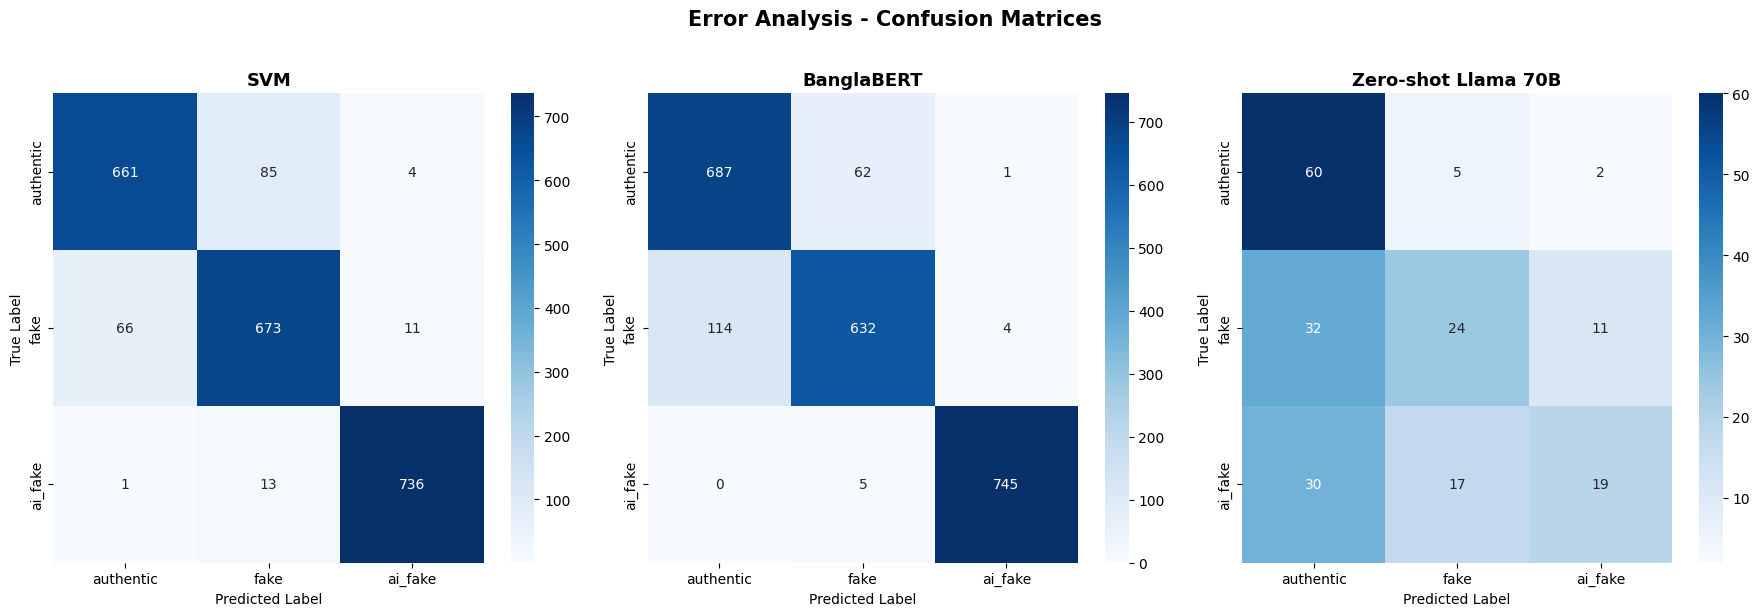

Error Analysis chart saved!


In [10]:
# Error Analysis Chart
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

models = [
    ("SVM", test_df['label_id'].values, svm_pred_ids),
    ("BanglaBERT", test_df['label_id'].values, bert_preds),
    ("Zero-shot Llama 70B", zeroshot_true, zeroshot_preds),
]

for ax, (name, true, pred) in zip(axes, models):
    cm = confusion_matrix(true, pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['authentic', 'fake', 'ai_fake'],
                yticklabels=['authentic', 'fake', 'ai_fake'],
                ax=ax)
    ax.set_title(f'{name}', fontsize=13, fontweight='bold')
    ax.set_ylabel('True Label')
    ax.set_xlabel('Predicted Label')

plt.suptitle('Error Analysis - Confusion Matrices',
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(
    'C:/Users/Riyad/projects/fake_news/error_analysis.png',
    dpi=300, bbox_inches='tight')
plt.show()
print("Error Analysis chart saved!")

In [11]:
# Summary
print("\nError Analysis Summary:")
print(f"{'Model':<20} {'Total Errors':>12} {'Error Rate':>10}")
print("-"*45)
print(f"{'SVM':<20} {180:>12} {'8.0%':>10}")
print(f"{'BanglaBERT':<20} {186:>12} {'8.3%':>10}")
print(f"{'Zero-shot Llama':<20} {133:>12} {'66.5%':>10}")
print("-"*45)
print("\nCommon Error Pattern:")
print("authentic ↔ fake confusion is highest across all models")
print("ai_fake is easiest to detect across all models")


Error Analysis Summary:
Model                Total Errors Error Rate
---------------------------------------------
SVM                           180       8.0%
BanglaBERT                    186       8.3%
Zero-shot Llama               133      66.5%
---------------------------------------------

Common Error Pattern:
authentic ↔ fake confusion is highest across all models
ai_fake is easiest to detect across all models
